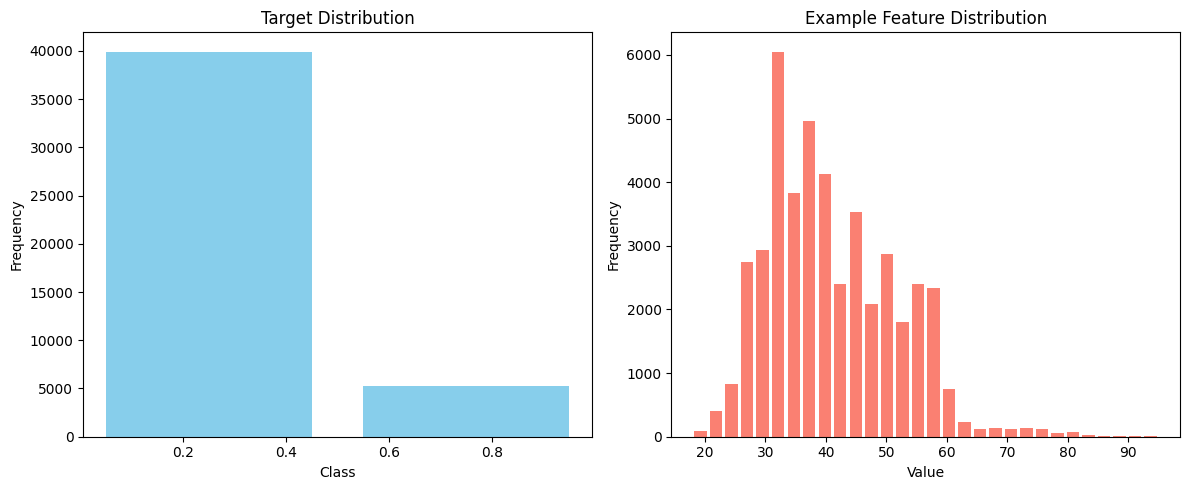

Starting to grow the decision tree...


Splitting at depth 0: feature 3 at threshold 472 (samples: 36168)


Splitting at depth 1: feature 40 at threshold False (samples: 31379)


Splitting at depth 1: feature 3 at threshold 827 (samples: 4789)


Decision tree training complete.

Decision Tree Classifier Evaluation:


Making predictions: 100%|██████████| 9043/9043 [00:00<00:00, 864342.81it/s]


Decision Tree Performance:
Accuracy:  0.9016
Precision: 0.5757
Recall:    0.4216
F1-score:  0.4867
ROC AUC:   0.6915



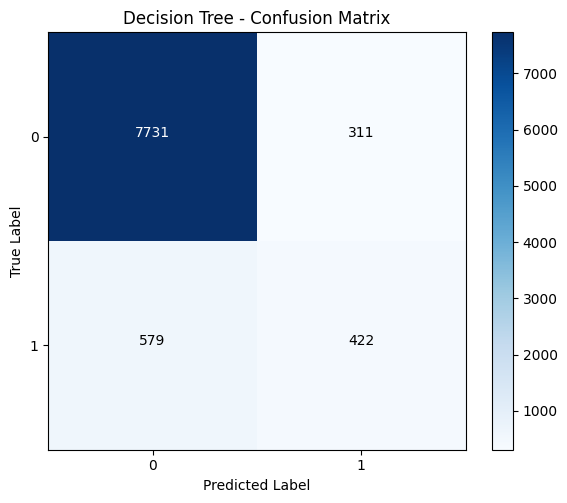

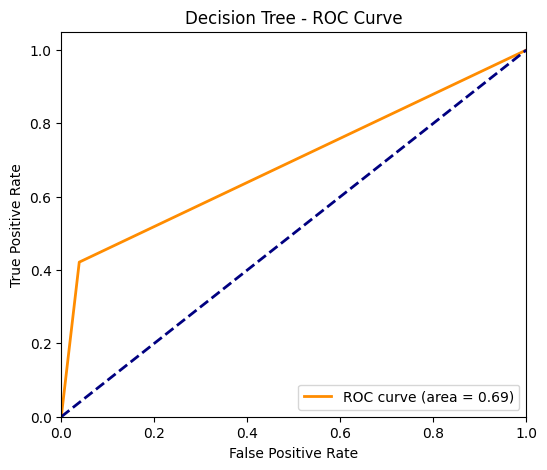

Starting Random Forest training...
Training tree 1/10 with 36168 samples...
Starting to grow the decision tree...


Splitting at depth 0: feature 6 at threshold 0 (samples: 36168)


Splitting at depth 1: feature 19 at threshold False (samples: 29594)


Splitting at depth 1: feature 38 at threshold False (samples: 6574)


Decision tree training complete.

Training tree 2/10 with 36168 samples...
Starting to grow the decision tree...


...

Splitting at depth 1: feature 35 at threshold False (samples: 35001)


Splitting at depth 1: feature 10 at threshold False (samples: 1167)


Decision tree training complete.

Random Forest training complete.

Random Forest Classifier Evaluation:


Making predictions: 100%|██████████| 9043/9043 [00:00<00:00, 715805.30it/s]


Random Forest Performance:
Accuracy:  0.9024
Precision: 0.6686
Recall:    0.2338
F1-score:  0.3464
ROC AUC:   0.8414



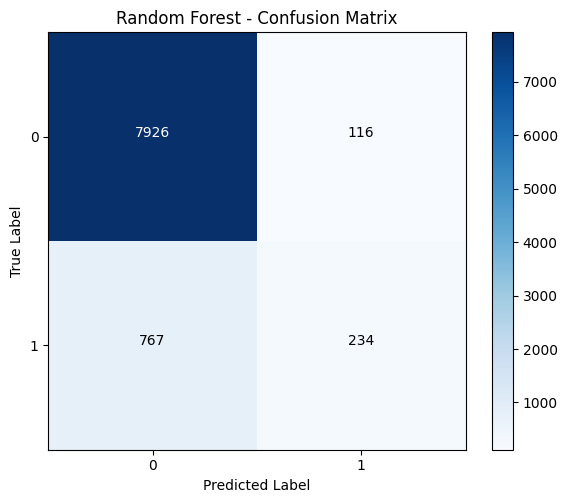

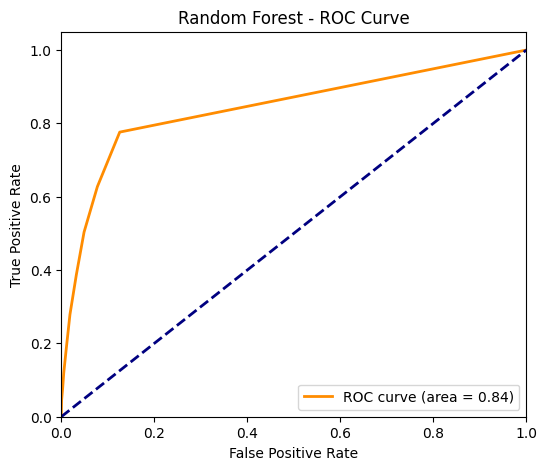

Comparison of Classifier Performance:
Metric		Decision Tree	Random Forest
accuracy  	0.9016		0.9024
precision 	0.5757		0.6686
recall    	0.4216		0.2338
f1        	0.4867		0.3464
roc_auc   	0.6915		0.8414


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split
from tqdm import tqdm

FilePath = 'X:/Projects/ML/Assignment-3/bank-full.csv'
DF = pd.read_csv(FilePath, sep=';')
DF = DF.dropna()
DF['Y'] = DF['y'].map({'yes': 1, 'no': 0})
DF = DF.drop(columns=['y'])  # Drop original target column

CategoricalCols = DF.select_dtypes(include=['object']).columns
DF = pd.get_dummies(DF, columns=CategoricalCols, drop_first=True)

XTrain, XTest, YTrain, YTest = train_test_split(
    DF.drop(columns=['Y']),
    DF['Y'],
    test_size=0.2,
    random_state=2022484
)

XTrain = XTrain.values
XTest = XTest.values
YTrain = YTrain.values
YTest = YTest.values

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(DF['Y'], bins=2, rwidth=0.8, color='skyblue')
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.subplot(1, 2, 2)
ExampleFeature = DF.iloc[:, 0]
plt.hist(ExampleFeature, bins=30, rwidth=0.8, color='salmon')
plt.title("Example Feature Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

class DecisionTreeNode:
    def __init__(self, FeatureIndex=None, Threshold=None, Left=None, Right=None, *, Value=None):
        self.FeatureIndex = FeatureIndex
        self.Threshold = Threshold
        self.Left = Left
        self.Right = Right
        self.Value = Value

class DecisionTreeClassifierScratch:
    def __init__(self, MaxDepth=10, MinSamplesSplit=2, NFeatures=None):
        self.MaxDepth = MaxDepth
        self.MinSamplesSplit = MinSamplesSplit
        self.NFeatures = NFeatures
        self.Root = None

    def Fit(self, X, Y):
        print("Starting to grow the decision tree...")
        self.NClasses = len(set(Y))
        self.NFeaturesTotal = X.shape[1]
        if self.NFeatures is None:
            self.NFeatures = self.NFeaturesTotal
        self.Root = self.GrowTree(X, Y)
        print("Decision tree training complete.\n")

    def Gini(self, Y):
        m = len(Y)
        return 1.0 - sum((np.sum(Y == c) / m) ** 2 for c in np.unique(Y))
    
    def BestSplit(self, X, Y):
        m, n = X.shape
        if m < self.MinSamplesSplit:
            return None, None
        Features = np.random.choice(n, self.NFeatures, replace=False)
        BestGain = 0.0
        SplitIdx, SplitThresh = None, None
        ParentGini = self.Gini(Y)
        for Feature in tqdm(Features, desc="Finding best split", leave=False):
            XColumn = X[:, Feature]
            Thresholds = np.unique(XColumn)
            for Thresh in Thresholds:
                LeftIndices = np.where(XColumn <= Thresh)[0]
                RightIndices = np.where(XColumn > Thresh)[0]
                if len(LeftIndices) == 0 or len(RightIndices) == 0:
                    continue
                NLeft, NRight = len(LeftIndices), len(RightIndices)
                GiniLeft = self.Gini(Y[LeftIndices])
                GiniRight = self.Gini(Y[RightIndices])
                WeightedGini = (NLeft / m) * GiniLeft + (NRight / m) * GiniRight
                Gain = ParentGini - WeightedGini
                if Gain > BestGain:
                    BestGain = Gain
                    SplitIdx = Feature
                    SplitThresh = Thresh
        return SplitIdx, SplitThresh

    def GrowTree(self, X, Y, Depth=0):
        NumSamples, NumFeatures = X.shape
        NumLabels = len(np.unique(Y))
        if Depth >= self.MaxDepth or NumLabels == 1 or NumSamples < self.MinSamplesSplit:
            LeafValue = self.MostCommonLabel(Y)
            return DecisionTreeNode(Value=LeafValue)
        FeatureIdx, Threshold = self.BestSplit(X, Y)
        if FeatureIdx is None:
            LeafValue = self.MostCommonLabel(Y)
            return DecisionTreeNode(Value=LeafValue)
        IndicesLeft = np.where(X[:, FeatureIdx] <= Threshold)[0]
        IndicesRight = np.where(X[:, FeatureIdx] > Threshold)[0]
        if Depth < 2:
            print(f"Splitting at depth {Depth}: feature {FeatureIdx} at threshold {Threshold} (samples: {NumSamples})")
        Left = self.GrowTree(X[IndicesLeft, :], Y[IndicesLeft], Depth + 1)
        Right = self.GrowTree(X[IndicesRight, :], Y[IndicesRight], Depth + 1)
        return DecisionTreeNode(FeatureIndex=FeatureIdx, Threshold=Threshold, Left=Left, Right=Right)

    def MostCommonLabel(self, Y):
        CounterY = Counter(Y)
        return CounterY.most_common(1)[0][0]

    def PredictOne(self, X, Node):
        if Node.Value is not None:
            return Node.Value
        if X[Node.FeatureIndex] <= Node.Threshold:
            return self.PredictOne(X, Node.Left)
        else:
            return self.PredictOne(X, Node.Right)

    def Predict(self, X):
        Predictions = [self.PredictOne(Sample, self.Root) for Sample in tqdm(X, desc="Making predictions")]
        return np.array(Predictions)

class RandomForestClassifierScratch:
    def __init__(self, NTrees=10, MaxDepth=10, MinSamplesSplit=2, NFeatures=None):
        self.NTrees = NTrees
        self.MaxDepth = MaxDepth
        self.MinSamplesSplit = MinSamplesSplit
        self.NFeatures = NFeatures
        self.Trees = []

    def Fit(self, X, Y):
        print("Starting Random Forest training...")
        self.Trees = []
        for i in range(self.NTrees):
            Indices = np.random.choice(len(Y), size=len(Y), replace=True)
            XSample = X[Indices]
            YSample = Y[Indices]
            print(f"Training tree {i + 1}/{self.NTrees} with {len(YSample)} samples...")
            Tree = DecisionTreeClassifierScratch(MaxDepth=self.MaxDepth,
                                                 MinSamplesSplit=self.MinSamplesSplit,
                                                 NFeatures=self.NFeatures)
            Tree.Fit(XSample, YSample)
            self.Trees.append(Tree)
        print("Random Forest training complete.\n")

    def Predict(self, X):
        TreePreds = np.array([Tree.Predict(X) for Tree in self.Trees])
        TreePreds = np.swapaxes(TreePreds, 0, 1)
        Predictions = [Counter(SamplePreds).most_common(1)[0][0] for SamplePreds in TreePreds]
        return np.array(Predictions)
    
    def PredictProba(self, X):
        TreePreds = np.array([Tree.Predict(X) for Tree in self.Trees])
        TreePreds = np.swapaxes(TreePreds, 0, 1)
        Proba = [np.mean(SamplePreds) for SamplePreds in TreePreds]
        return np.array(Proba)

def EvaluateModel(Model, XTest, YTest, ModelName="Model", UseProba=False):
    YPred = Model.Predict(XTest)
    if UseProba and hasattr(Model, 'PredictProba'):
        YProba = Model.PredictProba(XTest)
    else:
        YProba = YPred
    Acc = accuracy_score(YTest, YPred)
    Prec = precision_score(YTest, YPred, zero_division=0)
    Rec = recall_score(YTest, YPred, zero_division=0)
    F1 = f1_score(YTest, YPred, zero_division=0)
    try:
        AUC = roc_auc_score(YTest, YProba)
    except Exception:
        AUC = None
    print(f"{ModelName} Performance:")
    print(f"Accuracy:  {Acc:.4f}")
    print(f"Precision: {Prec:.4f}")
    print(f"Recall:    {Rec:.4f}")
    print(f"F1-score:  {F1:.4f}")
    if AUC is not None:
        print(f"ROC AUC:   {AUC:.4f}\n")
    else:
        print("ROC AUC:   Not Available")
    return {"accuracy": Acc, "precision": Prec, "recall": Rec, "f1": F1, "roc_auc": AUC, "YPred": YPred, "YProba": YProba}

def PlotConfusionMatrix(YTest, YPred, Title="Confusion Matrix"):
    CM = confusion_matrix(YTest, YPred)
    plt.figure(figsize=(6, 5))
    plt.imshow(CM, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(Title)
    plt.colorbar()
    TickMarks = np.arange(len(np.unique(YTest)))
    plt.xticks(TickMarks, TickMarks)
    plt.yticks(TickMarks, TickMarks)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    for i in range(CM.shape[0]):
        for j in range(CM.shape[1]):
            plt.text(j, i, format(CM[i, j], "d"), horizontalalignment="center", color="white" if CM[i, j] > CM.max()/2. else "black")
    plt.tight_layout()
    plt.show()

def PlotROCCurve(YTest, YScore, Title="ROC Curve"):
    Fpr, Tpr, _ = roc_curve(YTest, YScore)
    RocAuc = roc_auc_score(YTest, YScore)
    plt.figure(figsize=(6, 5))
    plt.plot(Fpr, Tpr, color="darkorange", lw=2, label=f"ROC curve (area = {RocAuc:.2f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(Title)
    plt.legend(loc="lower right")
    plt.show()

np.random.seed(2022484)

dtClassifier = DecisionTreeClassifierScratch(MaxDepth=10, MinSamplesSplit=5)
dtClassifier.Fit(XTrain, YTrain)
print("Decision Tree Classifier Evaluation:")
DtMetrics = EvaluateModel(dtClassifier, XTest, YTest, ModelName="Decision Tree", UseProba=False)
PlotConfusionMatrix(YTest, DtMetrics["YPred"], Title="Decision Tree - Confusion Matrix")
PlotROCCurve(YTest, DtMetrics["YPred"], Title="Decision Tree - ROC Curve")

rfClassifier = RandomForestClassifierScratch(
    NTrees=10,
    MaxDepth=10,
    MinSamplesSplit=5,
    NFeatures=int(np.sqrt(XTrain.shape[1]))
)
rfClassifier.Fit(XTrain, YTrain)
print("Random Forest Classifier Evaluation:")
RfMetrics = EvaluateModel(rfClassifier, XTest, YTest, ModelName="Random Forest", UseProba=True)
PlotConfusionMatrix(YTest, RfMetrics["YPred"], Title="Random Forest - Confusion Matrix")
PlotROCCurve(YTest, RfMetrics["YProba"], Title="Random Forest - ROC Curve")

print("Comparison of Classifier Performance:")
print("Metric\t\tDecision Tree\tRandom Forest")
for Metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    DtVal = DtMetrics.get(Metric, None)
    RfVal = RfMetrics.get(Metric, None)
    if DtVal is not None and RfVal is not None:
        print(f"{Metric:10s}\t{DtVal:.4f}\t\t{RfVal:.4f}")


#### Decision Tree:

- **Performance:**  
  - **Accuracy:** 90.16%  
  - **Precision:** 57.57%  
  - **Recall:** 42.16%  
  - **F1-score:** 48.67%  
  - **ROC AUC:** 69.15%

- **Strengths:**  
  - High recall and F1-score indicate the model captures a larger proportion of positive cases.  
  - Its single-tree structure is highly interpretable and can be easily visualized, aiding in understanding the decision process.

- **Weaknesses:**  
  - Lower precision and ROC AUC suggest the model is less effective at distinguishing between classes.  
  - Without advanced pruning, it is more prone to overfitting, which can hurt its generalization.

#### Random Forest:

- **Performance:**  
  - **Accuracy:** 90.24%  
  - **Precision:** 66.86%  
  - **Recall:** 23.38%  
  - **F1-score:** 34.64%  
  - **ROC AUC:** 84.14%

- **Strengths:**  
  - Higher precision and significantly improved ROC AUC demonstrate better class separation and reduced overfitting due to ensemble averaging.  
  - The ensemble approach yields more robust and stable predictions compared to a single decision tree.

- **Weaknesses:**  
  - Lower recall and F1-score indicate that the model may miss more positive cases.  
  - The ensemble nature reduces interpretability and increases computational complexity.

#### Conclusion:

Both models achieve similar overall accuracy (~90%), but they excel in different aspects. The Decision Tree offers clear interpretability and higher recall, making it useful when understanding the decision process and capturing a larger share of positive cases is crucial. In contrast, the Random Forest provides superior class discrimination, as evidenced by higher precision and ROC AUC, and is more robust due to variance reduction through ensemble learning—though at the expense of interpretability and recall. The choice between the two depends on whether your priority is model interpretability and capturing positives (Decision Tree) or achieving higher discrimination and stability (Random Forest).
